## Librerias

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from tkinter.messagebox import IGNORE
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.vector_ar.var_model import VAR
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
import keras_tuner as kt
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import tensorflow as tf


# VERIFICACION DATOS FALTANTES

In [2]:
# EXTRACION DE DATA PREPROCESADA
df_datos_preprocesados = pd.read_csv('../../data/processed/DATOS_PROCESADOS_temp_roc.csv')

In [3]:
df_pre_copy = df_datos_preprocesados.copy()

In [4]:
df_pre_copy.head()

,FECHA_REPORTE,Año,Mes,Dia,Hora,viento,temperatura,rocio
0,2006-07-20 00:00:00.000,2006,7,20,0,03004KT,13.0,8.0
1,2006-07-20 01:00:00.000,2006,7,20,1,29004KT,11.0,10.0
2,2006-07-20 05:00:00.000,2006,7,20,5,VRB02KT,9.0,9.0
3,2006-07-20 06:00:00.000,2006,7,20,6,VRB02KT,8.0,8.0
4,2006-07-20 07:00:00.000,2006,7,20,7,VRB02KT,9.0,8.0


valores nulos en temperatura y rocio

In [6]:
#contar el numero de registros donde las columnas de temperatura y punto de rocío son nulas vs cantidad de registros totales
total_registros = len(df_pre_copy)
nulos_temperatura = df_pre_copy['temperatura'].isnull().sum()
nulos_rocio = df_pre_copy['rocio'].isnull().sum()
print(f"Total de registros: {total_registros}")
print(f"Registros con temperatura nula: {nulos_temperatura} ({(nulos_temperatura / total_registros) * 100:.2f}%)")
print(f"Registros con punto de rocío nulo: {nulos_rocio} ({(nulos_rocio / total_registros) * 100:.2f}%)")
#mostrar registros con temperatura nula pero con punto de rocío no nulo
diferencias =df_pre_copy[(df_pre_copy['temperatura'].isnull()) & (df_pre_copy['rocio'].notnull())]
print(f"Registros con temperatura nula pero punto de rocío no nulo: {len(diferencias)}")
df_pre_copy[df_pre_copy['temperatura'].isnull()].head()

Total de registros: 169764
Registros con temperatura nula: 267 (0.16%)
Registros con punto de rocío nulo: 267 (0.16%)
Registros con temperatura nula pero punto de rocío no nulo: 0


,FECHA_REPORTE,Año,Mes,Dia,Hora,viento,temperatura,rocio
282,2006-09-05 10:00:00.000,2006,9,5,10,31003KT,NaN,NaN
401,2006-09-11 09:00:00.000,2006,9,11,9,VRB02KT,NaN,NaN
1066,2006-10-13 07:00:00.000,2006,10,13,7,30002KT,NaN,NaN
1420,2006-12-28 13:00:00.000,2006,12,28,13,02005KT,NaN,NaN
1874,2007-03-23 00:00:00.000,2007,3,23,0,VRB02KT,NaN,NaN


In [7]:
# Convertir FECHA_HORA_REPORTE a datetime y establecer como índice
df_pre_copy['FECHA_REPORTE'] = pd.to_datetime(df_pre_copy['FECHA_REPORTE'])
df_pre_copy.set_index('FECHA_REPORTE', inplace=True)

# Eliminación de variables no necesarias, solo me quedo con la columna de viento
df_pre_copy.drop(columns=['Año', 'Mes', 'Dia', 'Hora'], inplace=True)

# Eliminar valores nulos en la columna 'viento' antes de aplicar el parseo
df_pre_copy = df_pre_copy[df_pre_copy['viento'].notna()]

# Modificar el valor KKT, T, K  por KT en la columna de viento
df_pre_copy['viento'] = df_pre_copy['viento'].str.replace(r'[A-Za-z]{3}$', 'KT', regex=True)

def parse_viento_flexible(cadena):
    if pd.isna(cadena) or not isinstance(cadena, str):
        return pd.Series([None, None, None])

    patron = r'^(\d{3}|VRB)(\d{2,3})(G\d{2,3})?KT$'
    match = re.match(patron, cadena)

    if match:
        dir_raw = match.group(1)
        vel_raw = match.group(2)
        gus_raw = match.group(3)

        direccion = float(dir_raw) if dir_raw != 'VRB' else None
        velocidad = float(vel_raw)

        # CORRECCIÓN: Si no hay ráfaga (gus_raw es None), ponemos 0
        rafaga = float(gus_raw[1:]) if gus_raw else 0.0

        return pd.Series([direccion, velocidad, rafaga])

    return pd.Series([None, None, None])

# Aplicación Regex para parsear la columna de viento con formato flexible
df_pre_copy[['direccion', 'intensidad_kt', 'rafaga_kt']] = df_pre_copy['viento'].apply(parse_viento_flexible)

# Toma el último grado válido (ej. 030) y lo pone donde estaba el NaN de 'VRB'
df_pre_copy['direccion'] = df_pre_copy['direccion'].ffill()

# Elimino errores de digitación, por lo cual me quedo cuando la longitud de viento es mayor a 7
df_pre_copy = df_pre_copy[df_pre_copy['viento'].str.len() > 6]

# Elimino aquellos que no se identifica intensidad del viento
df_pre_copy = df_pre_copy[df_pre_copy["intensidad_kt"].notnull()]

# Verificar cuantos no tienen la estructura
df_pre_copy["viento"].str.len().value_counts()

# Eliminar valores donde la dirección es muy desfazada
df_pre_copy = df_pre_copy[df_pre_copy["direccion"] <= 360]


In [7]:
df_pre_copy.tail()

,viento,temperatura,rocio,direccion,intensidad_kt,rafaga_kt
FECHA_REPORTE,,,,,,
2026-04-09 14:27:00,16014G25KT,17.0,10.0,160.0,14.0,25.0
2026-04-09 15:00:00,15017KT,18.0,10.0,150.0,17.0,0.0
2026-04-09 16:00:00,18015KT,17.0,10.0,180.0,15.0,0.0
2026-04-09 17:00:00,15011KT,17.0,10.0,150.0,11.0,0.0
2026-04-09 18:00:00,17011KT,18.0,10.0,170.0,11.0,0.0


### Datos faltantes

In [9]:
# 1. Crear el horario maestro (ejemplo: cada 1 hora)
rango_teorico = pd.date_range(start=df_pre_copy.index.min().floor('h'),
                              end=df_pre_copy.index.max().ceil('h'),
                              freq='1h')

# 2. Identificar qué horas del maestro no están en tus datos
horas_faltantes = rango_teorico.difference(df_pre_copy.index)
print(f"Total de reportes faltantes: {len(horas_faltantes)}")

# Identificar reportes que no ocurren exactamente en la hora (minuto != 0)
reportes_especiales = df_pre_copy[df_pre_copy.index.minute != 0]
print(f"Reportes extra encontrados: {len(reportes_especiales)}")

Total de reportes faltantes: 13337
Reportes extra encontrados: 9782


#### Descomposicion de dirección e intensidad del viento

In [10]:
# =========================================================
# FASE 1: PREPARACIÓN DEL ÍNDICE Y CÁLCULO DE COMPONENTES
# =========================================================

# Asegurarnos de que el índice de dataset original es formato datetime
df_pre_copy.index = pd.to_datetime(df_pre_copy.index)

# PASO CRÍTICO: Redondear los reportes a la hora en punto más cercana.
# Esto sincroniza reportes emitidos al minuto 50-59 con la hora exacta.
df_pre_copy.index = df_pre_copy.index.round('h')

# Al redondear, un reporte regular y un reporte especial (SPECI) podrían caer
# en la misma hora. Conservamos el último (el más actualizado).
df_pre_copy = df_pre_copy[~df_pre_copy.index.duplicated(keep='last')]

# Calcular u y v desde cero:


radianes = df_pre_copy['direccion'] * (np.pi / 180)
df_pre_copy['u'] = -df_pre_copy['intensidad_kt'] * np.sin(radianes)
df_pre_copy['v'] = -df_pre_copy['intensidad_kt'] * np.cos(radianes)

In [11]:
df_pre_copy.head()

,viento,temperatura,rocio,direccion,intensidad_kt,rafaga_kt,u,v
FECHA_REPORTE,,,,,,,,
2006-07-20 00:00:00,03004KT,13.0,8.0,30.0,4.0,0.0,-2.000000,-3.464102
2006-07-20 01:00:00,29004KT,11.0,10.0,290.0,4.0,0.0,3.758770,-1.368081
2006-07-20 05:00:00,VRB02KT,9.0,9.0,290.0,2.0,0.0,1.879385,-0.684040
2006-07-20 06:00:00,VRB02KT,8.0,8.0,290.0,2.0,0.0,1.879385,-0.684040
2006-07-20 07:00:00,VRB02KT,9.0,8.0,290.0,2.0,0.0,1.879385,-0.684040


Los mejores datos a tomar para que luego de la imputacion ,no se presente mucho sesgo es desde el 2013 (inclusive).

In [12]:
# 1. Transformación Vectorial (u, v) - HACER ANTES DEL RESAMPLE


# 2. Definir reglas de agregación para tus columnas
reglas = {
    'u': 'mean',          # Promedio de la componente zonal
    'v': 'mean',
    'temperatura': 'mean', # Promedio de temperatura
    'rocio': 'mean'         # Promedio de la componente meridional
}

# 3. Forzar la frecuencia horaria (Resample)
df_modelo = df_pre_copy.resample('1h').agg(reglas)

# 4. Mantener la continuidad para el modelo (Interpolación)
# El LSTM requiere que no existan huecos en la secuencia
df_modelo['u'] = df_modelo['u'].interpolate(method='linear')
df_modelo['v'] = df_modelo['v'].interpolate(method='linear')
df_modelo['temperatura'] = df_modelo['temperatura'].interpolate(method='linear')
df_modelo['rocio'] = df_modelo['rocio'].interpolate(method='linear')

In [13]:
df_modelo.tail()

,u,v,temperatura,rocio
FECHA_REPORTE,,,,
2026-04-09 14:00:00,-4.788282e+00,13.155697,17.0,10.0
2026-04-09 15:00:00,-8.500000e+00,14.722432,18.0,10.0
2026-04-09 16:00:00,-1.836970e-15,15.000000,17.0,10.0
2026-04-09 17:00:00,-5.500000e+00,9.526279,17.0,10.0
2026-04-09 18:00:00,-1.910130e+00,10.832885,18.0,10.0


In [14]:
# Muestra la sumatoria de valores NaN en cada columna
print("Cantidad de valores faltantes por columna:")
print(df_modelo.isnull().sum())

# Verifica si la frecuencia horaria es estrictamente regular
print("\n¿Es el índice estrictamente regular (1H)?:", pd.infer_freq(df_modelo.index) == 'h')

Cantidad de valores faltantes por columna:
u              0
v              0
temperatura    0
rocio          0
dtype: int64

¿Es el índice estrictamente regular (1H)?: True


In [15]:
# 1. Asignar la frecuencia horaria de forma estricta
df_modelo = df_modelo.asfreq('h')

# 2. Verificar que la etiqueta 'freq' se haya asignado correctamente
print("Frecuencia oficial del índice:", df_modelo.index.freq)

Frecuencia oficial del índice: <Hour>


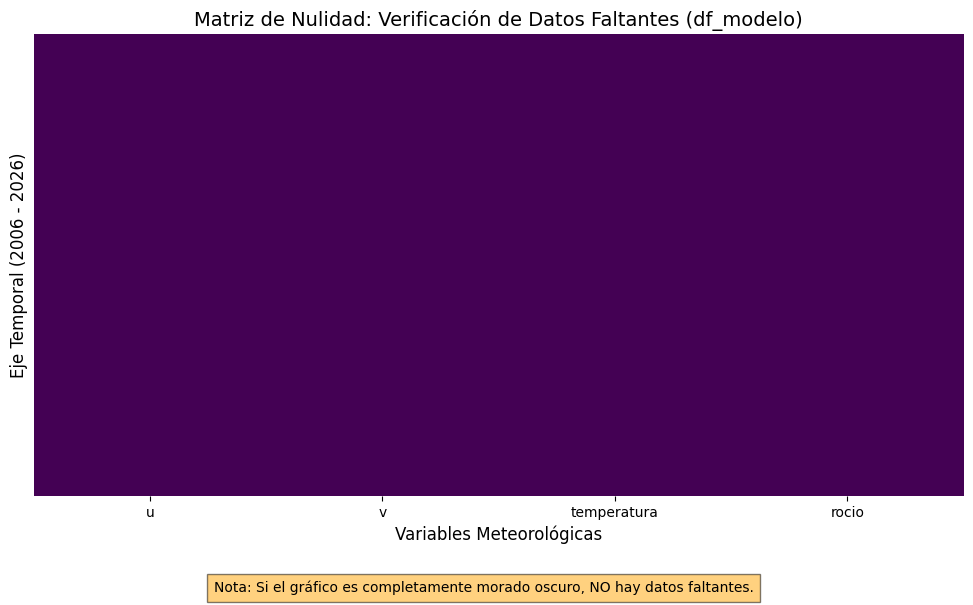

In [16]:
# Configurar el tamaño del gráfico
plt.figure(figsize=(12, 6))

# Crear un heatmap directamente sobre los valores booleanos de df.isnull()
# cbar=False quita la barra lateral, yticklabels=False oculta las miles de fechas del eje Y
sns.heatmap(df_modelo.isnull(), cbar=False, cmap='viridis', yticklabels=False)

plt.title('Matriz de Nulidad: Verificación de Datos Faltantes (df_modelo)', fontsize=14)
plt.xlabel('Variables Meteorológicas', fontsize=12)
plt.ylabel('Eje Temporal (2006 - 2026)', fontsize=12)

# Añadir un texto explicativo dentro del gráfico
plt.figtext(0.5, -0.05, "Nota: Si el gráfico es completamente morado oscuro, NO hay datos faltantes.",
            ha="center", fontsize=10, bbox={"facecolor":"orange", "alpha":0.5, "pad":5})

plt.show()

In [17]:
# Filtrar desde 2013
df_lstm = df_modelo.loc['2013-01-01':, ['u', 'v', 'temperatura', 'rocio']].copy()

In [18]:
# "/content/drive/MyDrive/MAESTRIA/
ruta_exportacion = '../../data/processed/DATOS_ENTRENAMIENTO_temp_roc_u_v.csv'

# Verificar que el directorio existe (crearlo si no existe)
#import os
#directorio = os.path.dirname(ruta_exportacion)
#if not os.path.exists(directorio):
#    os.makedirs(directorio, exist_ok=True)
#    print(f" Directorio creado: {directorio}")

# Exportar a CSV
df_lstm.to_csv(ruta_exportacion, index=False)

In [19]:
df_lstm.head()

,u,v,temperatura,rocio
FECHA_REPORTE,,,,
2013-01-01 00:00:00,-0.520945,-2.954423,14.0,6.0
2013-01-01 01:00:00,-2.500000,-4.330127,13.0,7.0
2013-01-01 02:00:00,-2.819078,-1.026060,13.0,7.0
2013-01-01 03:00:00,-1.500000,-2.598076,10.0,7.0
2013-01-01 04:00:00,-2.000000,-3.464102,9.0,7.0


In [20]:
df_lstm.describe()

,u,v,temperatura,rocio
count,116323.000000,116323.000000,116323.000000,116323.000000
mean,-0.868066,-0.268676,14.168299,9.708768
std,5.191485,5.135471,4.888509,3.343116
min,-94.541544,-889.281401,1.000000,0.000000
25%,-3.856726,-2.954423,12.000000,8.000000
50%,-1.349706,-1.532089,14.000000,10.000000
75%,1.732051,1.532089,17.000000,11.000000
max,781.154914,118.176930,717.000000,809.000000


# PRUEBA DE MODELOS

## LSTM

In [73]:
features_modelo = ['u', 'v']
targets = ['u','v']
# ========== 1. PARTICIÓN CRONOLÓGICA PRIMERO ==========
print("Realizando partición cronológica antes de escalar...")

train_df = df_lstm.loc[:'2024-12-31'].copy()
val_df = df_lstm.loc['2025-01-01':'2025-12-31'].copy()
test_df = df_lstm.loc['2026-01-01':].copy()

# ========== 2. NORMALIZACIÓN (EVITANDO LEAKAGE) ==========
print("Normalizando variables correctamente...")

# ========== 1. ENTRENAMIENTO DE ESCALADORES (Fit) ==========
# Se ajustan ÚNICAMENTE con los datos crudos de entrenamiento
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Ajustamos ambos (aunque sean iguales, mantenemos la lógica de X e y)
scaler_X.fit(train_df[features_modelo])
scaler_y.fit(train_df[targets])

# ========== 2. TRANSFORMACIÓN (Transform) ==========
# IMPORTANTE: Transformamos y asignamos a variables nuevas para evitar el re-escalamiento 
# accidental de las columnas del DataFrame original en la misma celda.

# Train
X_train_scaled = scaler_X.transform(train_df[features_modelo])
y_train_scaled = scaler_y.transform(train_df[targets])

# Validation
X_val_scaled   = scaler_X.transform(val_df[features_modelo])
y_val_scaled   = scaler_y.transform(val_df[targets])

# Test
X_test_scaled  = scaler_X.transform(test_df[features_modelo])
y_test_scaled  = scaler_y.transform(test_df[targets])

print(f"Media de scaler_y: {scaler_y.mean_}")
print(f"Escala de scaler_y: {scaler_y.scale_}")

Realizando partición cronológica antes de escalar...
Normalizando variables correctamente...
Media de scaler_y: [-0.90920821 -0.24399109]
Escala de scaler_y: [5.28395897 5.26741466]


Generación secuencias para LSTM

In [60]:
# ========== 1. ASIGNACIÓN DE TENSORES (POST-ESCALAMIENTO) ==========
# Ya no extraemos del DataFrame porque los objetos X_train_scaled, etc.
# ya son arrays de NumPy con los datos normalizados correctamente.

Xtrain_data = X_train_scaled
y_train     = y_train_scaled

Xval_data   = X_val_scaled
y_val       = y_val_scaled

Xtest_data  = X_test_scaled
y_test      = y_test_scaled

print("Tensores asignados exitosamente desde variables escaladas.")

Tensores asignados exitosamente desde variables escaladas.


In [61]:
# ========== 2. CONFIGURACIÓN DE GENERADORES ==========

# Parámetros metodológicos
n_back = 20           # Ventana de timesteps (rezagos)
batch_size_train = 300 
batch_size_test = 1    

# Generador de Entrenamiento: Aprende patrones con el escalamiento de 2013-2024
train_generator = TimeseriesGenerator(
    Xtrain_data, 
    y_train,
    length=n_back, 
    batch_size=batch_size_train
)

# Generador de Validación: Evalúa el desempeño en 2025 (escalado con parámetros de train)
val_generator = TimeseriesGenerator(
    Xval_data, 
    y_val, 
    length=n_back, 
    batch_size=batch_size_train # Usamos batch grande para acelerar validación
)

# Generador de Prueba: Evaluación final 2026 (Inferencia uno a uno)
test_generator = TimeseriesGenerator(
    Xtest_data, 
    y_test, 
    length=n_back, 
    batch_size=batch_size_test
)

# ========== 3. VERIFICACIÓN TÉCNICA DE TENSORES ==========
x_batch, y_batch = train_generator[0]
print("--- Diagnóstico de Estructura de Datos ---")
print(f"Input Shape (X): {x_batch.shape} -> (Batch, Ventana, Features)")
print(f"Target Shape (y): {y_batch.shape} -> (Batch, Targets)")

# Verificación de valores (opcional para control de calidad)
print(f"Media aproximada en Train (X): {x_batch.mean():.4f} (debería ser cercana a 0)")

--- Diagnóstico de Estructura de Datos ---
Input Shape (X): (300, 20, 2) -> (Batch, Ventana, Features)
Target Shape (y): (300, 2) -> (Batch, Targets)
Media aproximada en Train (X): -0.1159 (debería ser cercana a 0)


Entrenamiento modelo LSTM

In [62]:
# Número de variables entradas (u,v, temperatura, rocio)
n_features = 2
n_outputs = 2  # Solo queremos predecir u,v
neuronas_ocultas = 300

# 1. Diseño de la Arquitectura del Modelo (Estrictamente 3 capas)
model = Sequential()

# Capa 1: Entrada
model.add(Input(shape=(n_back, n_features)))

# Capa 2: Única Capa Oculta LSTM
model.add(LSTM(
    units=neuronas_ocultas,
    activation='tanh',               # Estándar del estudio
    recurrent_activation='sigmoid'   # Estándar del estudio para las gates
))

# Capa 3: Capa de salida
model.add(Dense(
    units=n_outputs, 
    activation='linear'              # Estándar del estudio para regresión
))

# 2. Compilación
# El estudio empleó Adam con sus valores por defecto en TensorFlow y MSE
model.compile(optimizer=Adam(), loss='mse')
print("Estructura de la Red Neuronal del Proyecto (Alves et al., 2024):")
model.summary()

# Callbacks para early stopping (Paciencia de 10 épocas según el estudio)
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True)
]

# 3. Entrenamiento
num_epochs = 50


Estructura de la Red Neuronal del Proyecto (Alves et al., 2024):


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 300)            │       363,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 2)              │           602 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 364,202 (1.39 MB)

 Trainable params: 364,202 (1.39 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 27s 72ms/step - loss: 0.6438 - val_loss: 0.2538
Epoch 2/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 29s 83ms/step - loss: 0.6056 - val_loss: 0.2630
Epoch 3/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 50s 143ms/step - loss: 0.6056 - val_loss: 0.2521
Epoch 4/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 39s 110ms/step - loss: 0.6016 - val_loss: 0.2449
Epoch 5/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 34s 96ms/step - loss: 0.5992 - val_loss: 0.2451
Epoch 6/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 30s 85ms/step - loss: 0.5972 - val_loss: 0.2456
Epoch 7/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 29s 83ms/step - loss: 0.5956 - val_loss: 0.2493
Epoch 8/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 31s 88ms/step - loss: 0.5955 - val_loss: 0.2441
Epoch 9/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 34s 97ms/step - loss: 0.5943 - val_loss: 0.2508
Epoch 10/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 35s 100ms/step - loss: 0.5935 - val_loss: 0.2440
Epoch 11/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 34s 98ms/step - loss: 0.5931 - val_loss: 0.2426
Epoch 12/50
351/351 ━━━━━━━

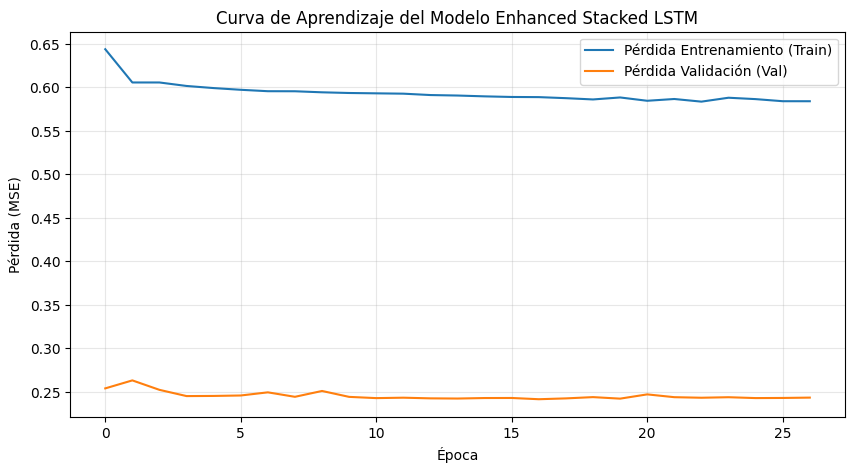

In [63]:

# Al llamar a model.fit, asegúrate de incluir el batch_size de 512 que usó el estudio:
history = model.fit(
    train_generator, 
    validation_data=val_generator, 
    epochs=num_epochs, 
    batch_size=512,          # ¡Dato crítico del estudio!
    callbacks=callbacks, 
    verbose=1 
)


# 4. Visualización de la Curva de Aprendizaje
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Pérdida Entrenamiento (Train)')
plt.plot(history.history['val_loss'], label='Pérdida Validación (Val)')
plt.title('Curva de Aprendizaje del Modelo Enhanced Stacked LSTM')
plt.xlabel('Época')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Prueba de oncepto a 6h

In [64]:
def predict_autoregressive_uv(modelo, initial_window, horizon):
    """
    Realiza el pronóstico iterativo usando solo componentes u y v.
    - initial_window: Array con forma (1, n_back, 2)
    - horizon: Pasos de tiempo a predecir (ej. 6)
    """
    current_window = np.copy(initial_window)
    predictions = []
    
    for _ in range(horizon):
        # 1. Inferencia: El modelo recibe (1, 48, 2) y devuelve (1, 2) -> [u, v]
        next_uv = modelo.predict(current_window, verbose=0) 
        predictions.append(next_uv[0])
        
        # 2. Reshape para añadir un nuevo timestep: (1, 1, 2)
        next_step_3d = next_uv.reshape(1, 1, 2)
        
        # 3. Actualizar ventana: Deslizar (quitar el primero) y añadir la predicción
        current_window = np.concatenate(
            [current_window[:, 1:, :], next_step_3d],
            axis=1
        )
    
    return np.array(predictions) # Forma (6, 2)

In [65]:
def convertir_predicciones(predictions_escaladas, scaler_y):
    """
    Convierte predicciones normalizadas de [u, v] a [Dirección, Intensidad].
    """
    # 1. Inversa del escalado (Z-score -> Unidades reales de u y v)
    # Importante: predictions_escaladas debe tener forma (horizonte, 2)
    predictions = scaler_y.inverse_transform(predictions_escaladas)
    
    u_pred = predictions[:, 0]
    v_pred = predictions[:, 1]

    # 2. Recuperar Intensidad (Pitágoras)
    # Resultado en las unidades originales (kt - nudos)
    intensidad_pred = np.sqrt(u_pred**2 + v_pred**2)
    
    # 3. Recuperar Dirección (Trigonometría Inversa)
    # Dado que u = -I*sin(theta) y v = -I*cos(theta)
    # La fórmula correcta para recuperar el ángulo de "donde viene" es:
    radianes_recuperados = np.arctan2(-u_pred, -v_pred)
    
    # Convertir a grados y asegurar rango [0, 360)
    direccion_pred = (radianes_recuperados * 180 / np.pi) % 360
    
    return direccion_pred, intensidad_pred

In [66]:
# Definir horizonte de predicción
horizonte_pred = 6

# 1. Extraer las últimas 48 horas del set de validación
# Xval_data ya está escalado y tiene forma (N, 2)
ultima_ventana_val = Xval_data[-n_back:]  # Forma: (48, 2)

# 2. Expandir a 3D para que Keras lo procese (Batch, Time, Features)
# Forma resultante: (1, 48, 2)
ultima_ventana_val_3d = np.expand_dims(ultima_ventana_val, axis=0)

In [67]:
# Generar el pronóstico en escala normalizada (Z-score)
print("Generando pronóstico autoregresivo...")

forecast_escalado = predict_autoregressive_uv(
    model, 
    ultima_ventana_val_3d, 
    horizon=horizonte_pred
)

print(f"Variable 'forecast_escalado' generada. Forma: {forecast_escalado.shape}")
# Debería mostrar (6, 2)

Generando pronóstico autoregresivo...
Variable 'forecast_escalado' generada. Forma: (6, 2)


In [68]:
forecast_escalado

array([[-0.42502838, -0.38601732],
       [-0.2805276 , -0.35365796],
       [-0.23880322, -0.39249355],
       [-0.22764836, -0.420807  ],
       [-0.21918188, -0.43549848],
       [-0.21748711, -0.4427945 ]], dtype=float32)

In [81]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error

def evaluar_modelo_mse_369(modelo, data_X_escalada, data_y_escalada, scaler_y, 
                           seq_length=20, horizon=9, dataset_name="Test", umbral_calma=2.0):
    
    # 1. Definir exactamente las horas que quieres evaluar
    franjas_objetivo = [3, 6, 9]
    
    # 2. Diccionario para guardar los resultados
    resultados_h = {h: {'int_real': [], 'int_pred': [], 'dir_real': [], 'dir_pred': []} 
                    for h in franjas_objetivo}
    
    print(f"Iniciando evaluación (MSE) con ventana de {seq_length}h para {dataset_name}...")

    # 3. Ventana Deslizante (step=1 para evaluar cada bloque posible del dataset)
    for t in range(seq_length, len(data_X_escalada) - horizon, 1):
        
        # Tomar las 20 horas previas (forma: 1, 20, 2)
        ventana_actual_3d = np.expand_dims(data_X_escalada[t - seq_length : t], axis=0)
        
        # Predecir iterativamente hasta la hora 9
        forecast_escalado = predict_autoregressive_uv(modelo, ventana_actual_3d, horizon)
        
        # Desescalar a Nudos (Z-score -> kt)
        forecast_real = scaler_y.inverse_transform(forecast_escalado)
        real_real     = scaler_y.inverse_transform(data_y_escalada[t : t + horizon])
        
        for h_idx in range(horizon):
            paso = h_idx + 1
            
            # Solo guardamos datos si el 'paso' es 3, 6 o 9
            if paso in franjas_objetivo:
                # --- REALES ---
                u_r, v_r = real_real[h_idx]
                int_r_kt = np.sqrt(u_r**2 + v_r**2)
                dir_r = np.degrees(np.arctan2(-u_r, -v_r)) % 360
                
                # --- PREDICCIONES ---
                u_p, v_p = forecast_real[h_idx]
                int_p_kt = np.sqrt(u_p**2 + v_p**2)
                dir_p = np.degrees(np.arctan2(-u_p, -v_p)) % 360
                
                # Guardar intensidad
                resultados_h[paso]['int_real'].append(int_r_kt)
                resultados_h[paso]['int_pred'].append(int_p_kt)
                
                # Guardar dirección (aplicando umbral de vientos calmos FMH-1)
                if int_r_kt >= umbral_calma:
                    resultados_h[paso]['dir_real'].append(dir_r)
                    resultados_h[paso]['dir_pred'].append(dir_p)

    # 4. Cálculo de MSE y RMSE
    reporte = pd.DataFrame(index=[f"Hora {h}" for h in franjas_objetivo], 
                           columns=['MSE_Intensidad (kt²)', 'RMSE_Direccion (grados)'])
    
    for h in franjas_objetivo:
        i_r = np.array(resultados_h[h]['int_real'])
        i_p = np.array(resultados_h[h]['int_pred'])
        
        d_r = np.array(resultados_h[h]['dir_real'])
        d_p = np.array(resultados_h[h]['dir_pred'])
        
        # MSE de Intensidad
        mse_int = mean_squared_error(i_r, i_p)
        
        # RMSE de Dirección (Métrica Circular)
        diff = np.abs(d_r - d_p)
        error_circular = np.minimum(diff, 360 - diff)
        mse_dir_circular = np.mean(error_circular**2) # Calculamos MSE circular...
        rmse_dir = np.sqrt(mse_dir_circular)          # ...y sacamos la raíz para volver a grados
        
        reporte.loc[f"Hora {h}"] = [mse_int, rmse_dir]
        
    print(f"\n--- REPORTE FINAL: {dataset_name.upper()} ---")
    print(reporte.astype(float).round(2))
    return reporte

In [82]:
# Evaluar en Validación (2025)
reporte_val_lstm = evaluar_modelo_mse_369(
    model, Xval_data, y_val, scaler_y,
    seq_length=n_back, horizon=horizonte_pred, dataset_name="Validación (2025)"
)

Iniciando evaluación (MSE) con ventana de 20h para Validación (2025)...


ValueError: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.